In [1]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
from scipy.special import erf
import pyopencl as cl

%matplotlib notebook

plt.close()

# User Defined Parameters

In [4]:
### Beamline Parameters ###
Beamline = 'P10' #P10 or 8IDE
Geometry = 'Horizontal' #Horizontal or Vertical
Compound = 'NPS'

### Analysis Parameters ###


### File Parameters ###
Particle = 2 #2,3
Temperatures = np.array([298,305,315,325,345,365,385,405,350])
Scans = np.array([219,334,416,552,579,709,779,796,868]) # P3:[239,356
Attenuation = 20

Temperature = Temperatures[0]
Scan = Scans[0]
#Crop Size
#number of standard deviations from peak
Xv = 5
Xh = 5

# File Paths

In [88]:
paths_list = []

for Temperature, Scan in zip(Temperatures,Scans):
    
    if Compound == 'NBH':
        results_path = f'/Volumes/Eriks_4TB/APSU_1004574_shpyrko202411/A{Scan}_NaBH_att0000{Attenuation}_{Temperature}K_001/result/'
    if Compound == 'NPS':
        results_path = f'/Users/eriklamb/Documents/Data/PETRA/PETRA_P10_November2023/Beamtime_11017686/XPCS_Scans/Particle_{Particle}/{Temperature}K/NPS_01_00{Scan}/result/'

    #Check that path exists
    if not os.path.exists(results_path):
        print(f"Directory '{results_path}' Does Not Exist!")

    #Load File Names
    file_list = np.sort(os.listdir(results_path)).tolist()

    #Remove first element if it's DS_Store
    if file_list[0] == '.DS_Store':
        file_list.remove(file_list[0])

    #Removes strange file that occurs if you edit batchinfo
    if file_list[0][0:2] == '._':
        file_list.remove(file_list[0])

    #for f in file_list:
        #print(f)

    #Retrieve number of files
    num_files = len(file_list)
    
    paths_list.append(results_path+file_list[-1])
    
#print(paths_list)   

# Load Data

In [91]:
# first load

results = h5py.File(paths_list[0], 'r')

dQ = results['data/dQ'][:][np.newaxis]
taus = results['XPCS/taus'][:][np.newaxis]
taus_err = results['XPCS/taus_err'][:][np.newaxis]
betas = results['XPCS/betas'][:][np.newaxis]
betas_err = results['XPCS/betas_err'][:][np.newaxis]
As = results['XPCS/As'][:][np.newaxis]
As_err = results['XPCS/As_err'][:][np.newaxis]
Cs = results['XPCS/Cs'][:][np.newaxis]
Cs_err = results['XPCS/Cs_err'][:][np.newaxis]
T = np.array([paths_list[0][-47:-44]])

results.close()

print(dQ.shape)


for file in paths_list[1:]:
    results = h5py.File(file, 'r')
    
    dQ = np.append(dQ,results['XPCS/dQ'][:][np.newaxis],axis=0)
        
    taus = np.append(taus,results['XPCS/taus'][:][np.newaxis],axis=0)
    taus_err = np.append(taus_err,results['XPCS/taus_err'][:][np.newaxis],axis=0)
    
    betas = np.append(betas,results['XPCS/betas'][:][np.newaxis],axis=0)
    betas_err = np.append(betas_err,results['XPCS/betas_err'][:][np.newaxis],axis=0)
    
    As = np.append(As,results['XPCS/As'][:][np.newaxis],axis=0)
    As_err = np.append(As_err,results['XPCS/As_err'][:][np.newaxis],axis=0)
    
    Cs = np.append(Cs,results['XPCS/Cs'][:][np.newaxis],axis=0)
    Cs_err = np.append(Cs_err,results['XPCS/Cs_err'][:][np.newaxis],axis=0)
    
    T = np.append(T,file[-47:-44])

    results.close()
    

(1, 18)


In [104]:
np.mean(dQ.T,axis=0).shape

(9,)

# Plotting

<IPython.core.display.Javascript object>


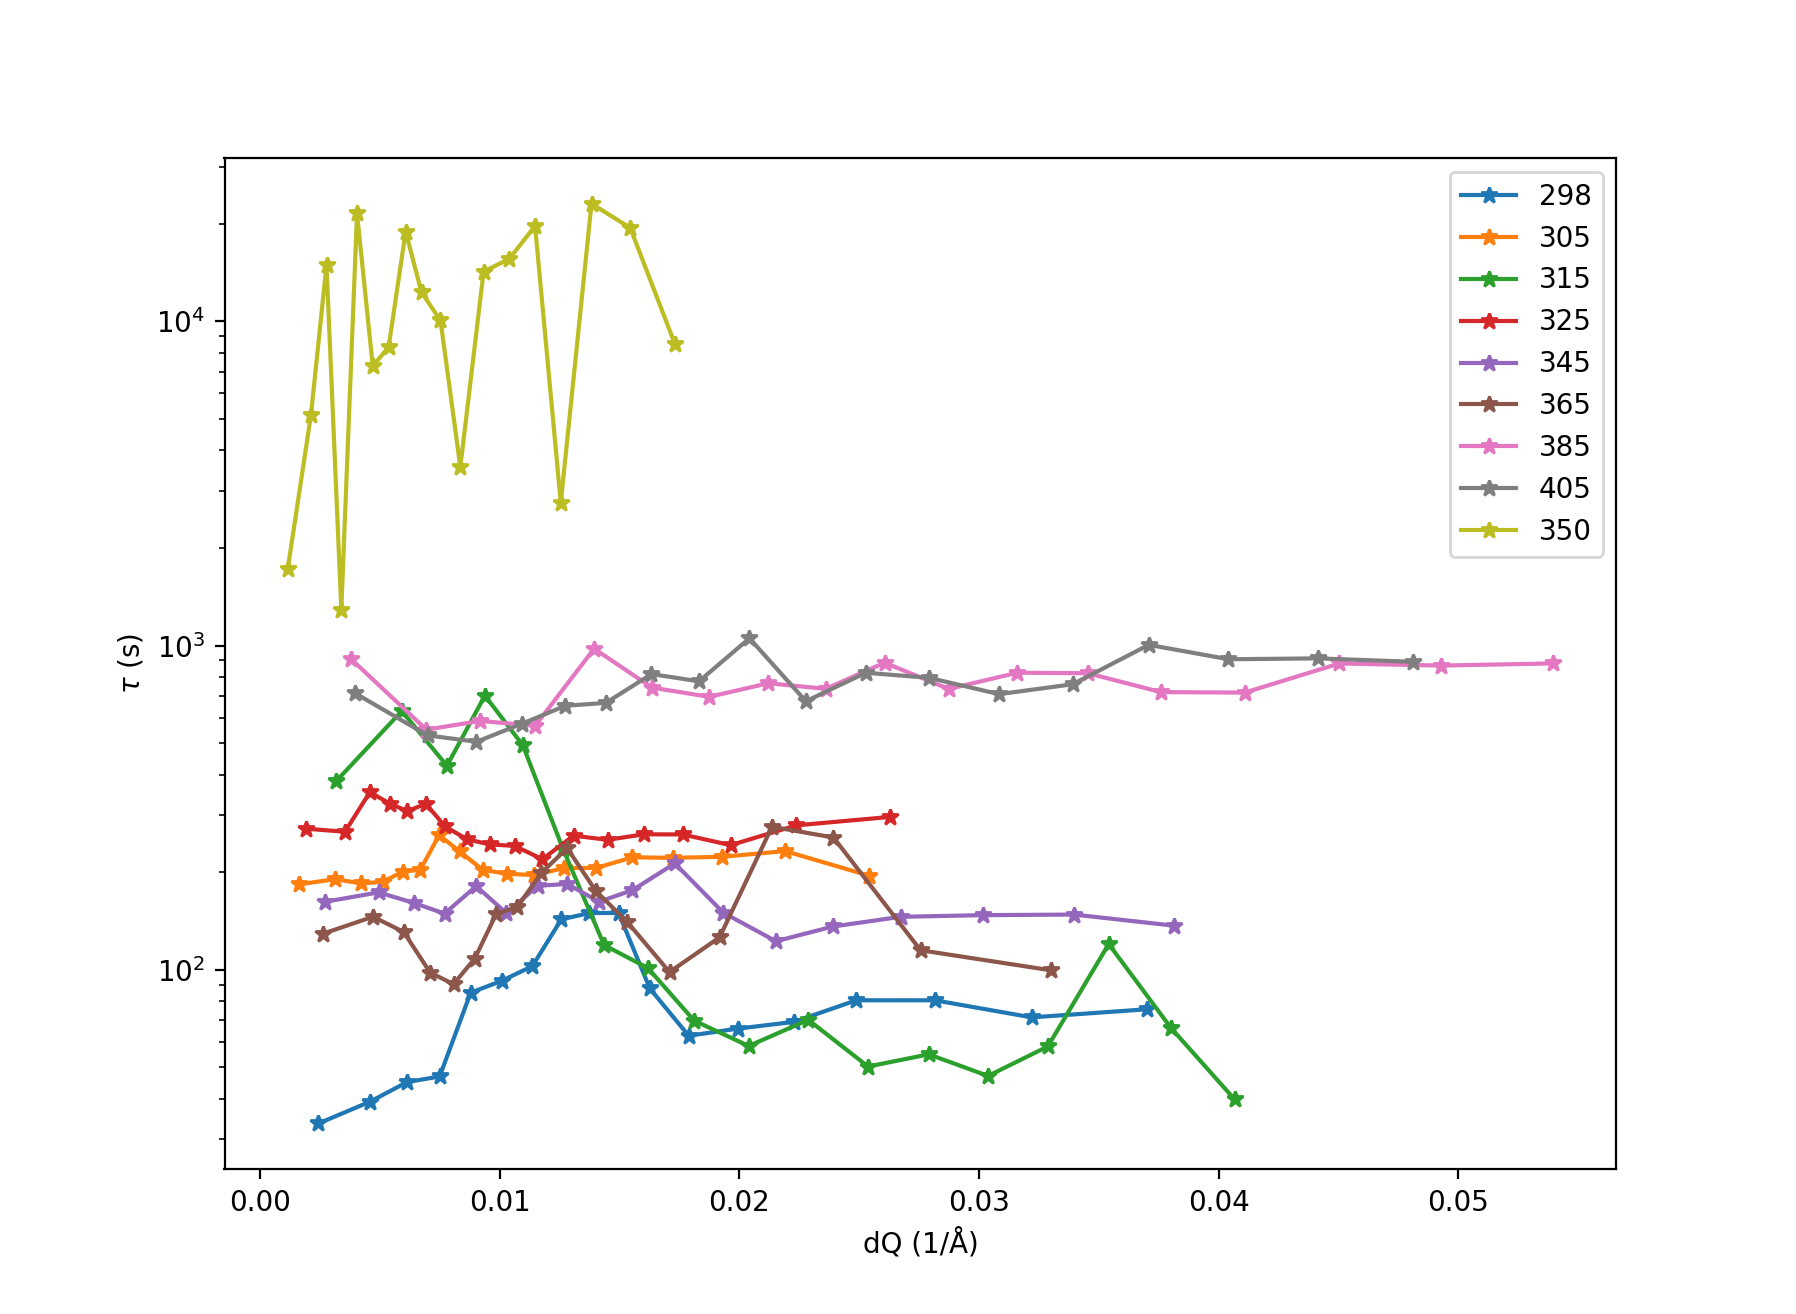

In [121]:
fig, ax = plt.subplots()

ax.set_ylabel('$\\tau$ (s)')
ax.set_xlabel('dQ (1/Å)')


for t in range(taus.shape[0]):
    ax.semilogy(dQ[t,:],taus[t,:],'-*',label=T[t])
    ax.legend(loc = 'upper right')
    
plt.show()


    #axs[0].errorbar(dQ,taus, yerr=taus_err,fmt='none',ecolor='b',capsize=2)
    #axs[0].semilogy(dQ,taus,'-*',label=file[-47:-44]+'K')
    #axs[0].legend(loc = 'center right')

<IPython.core.display.Javascript object>


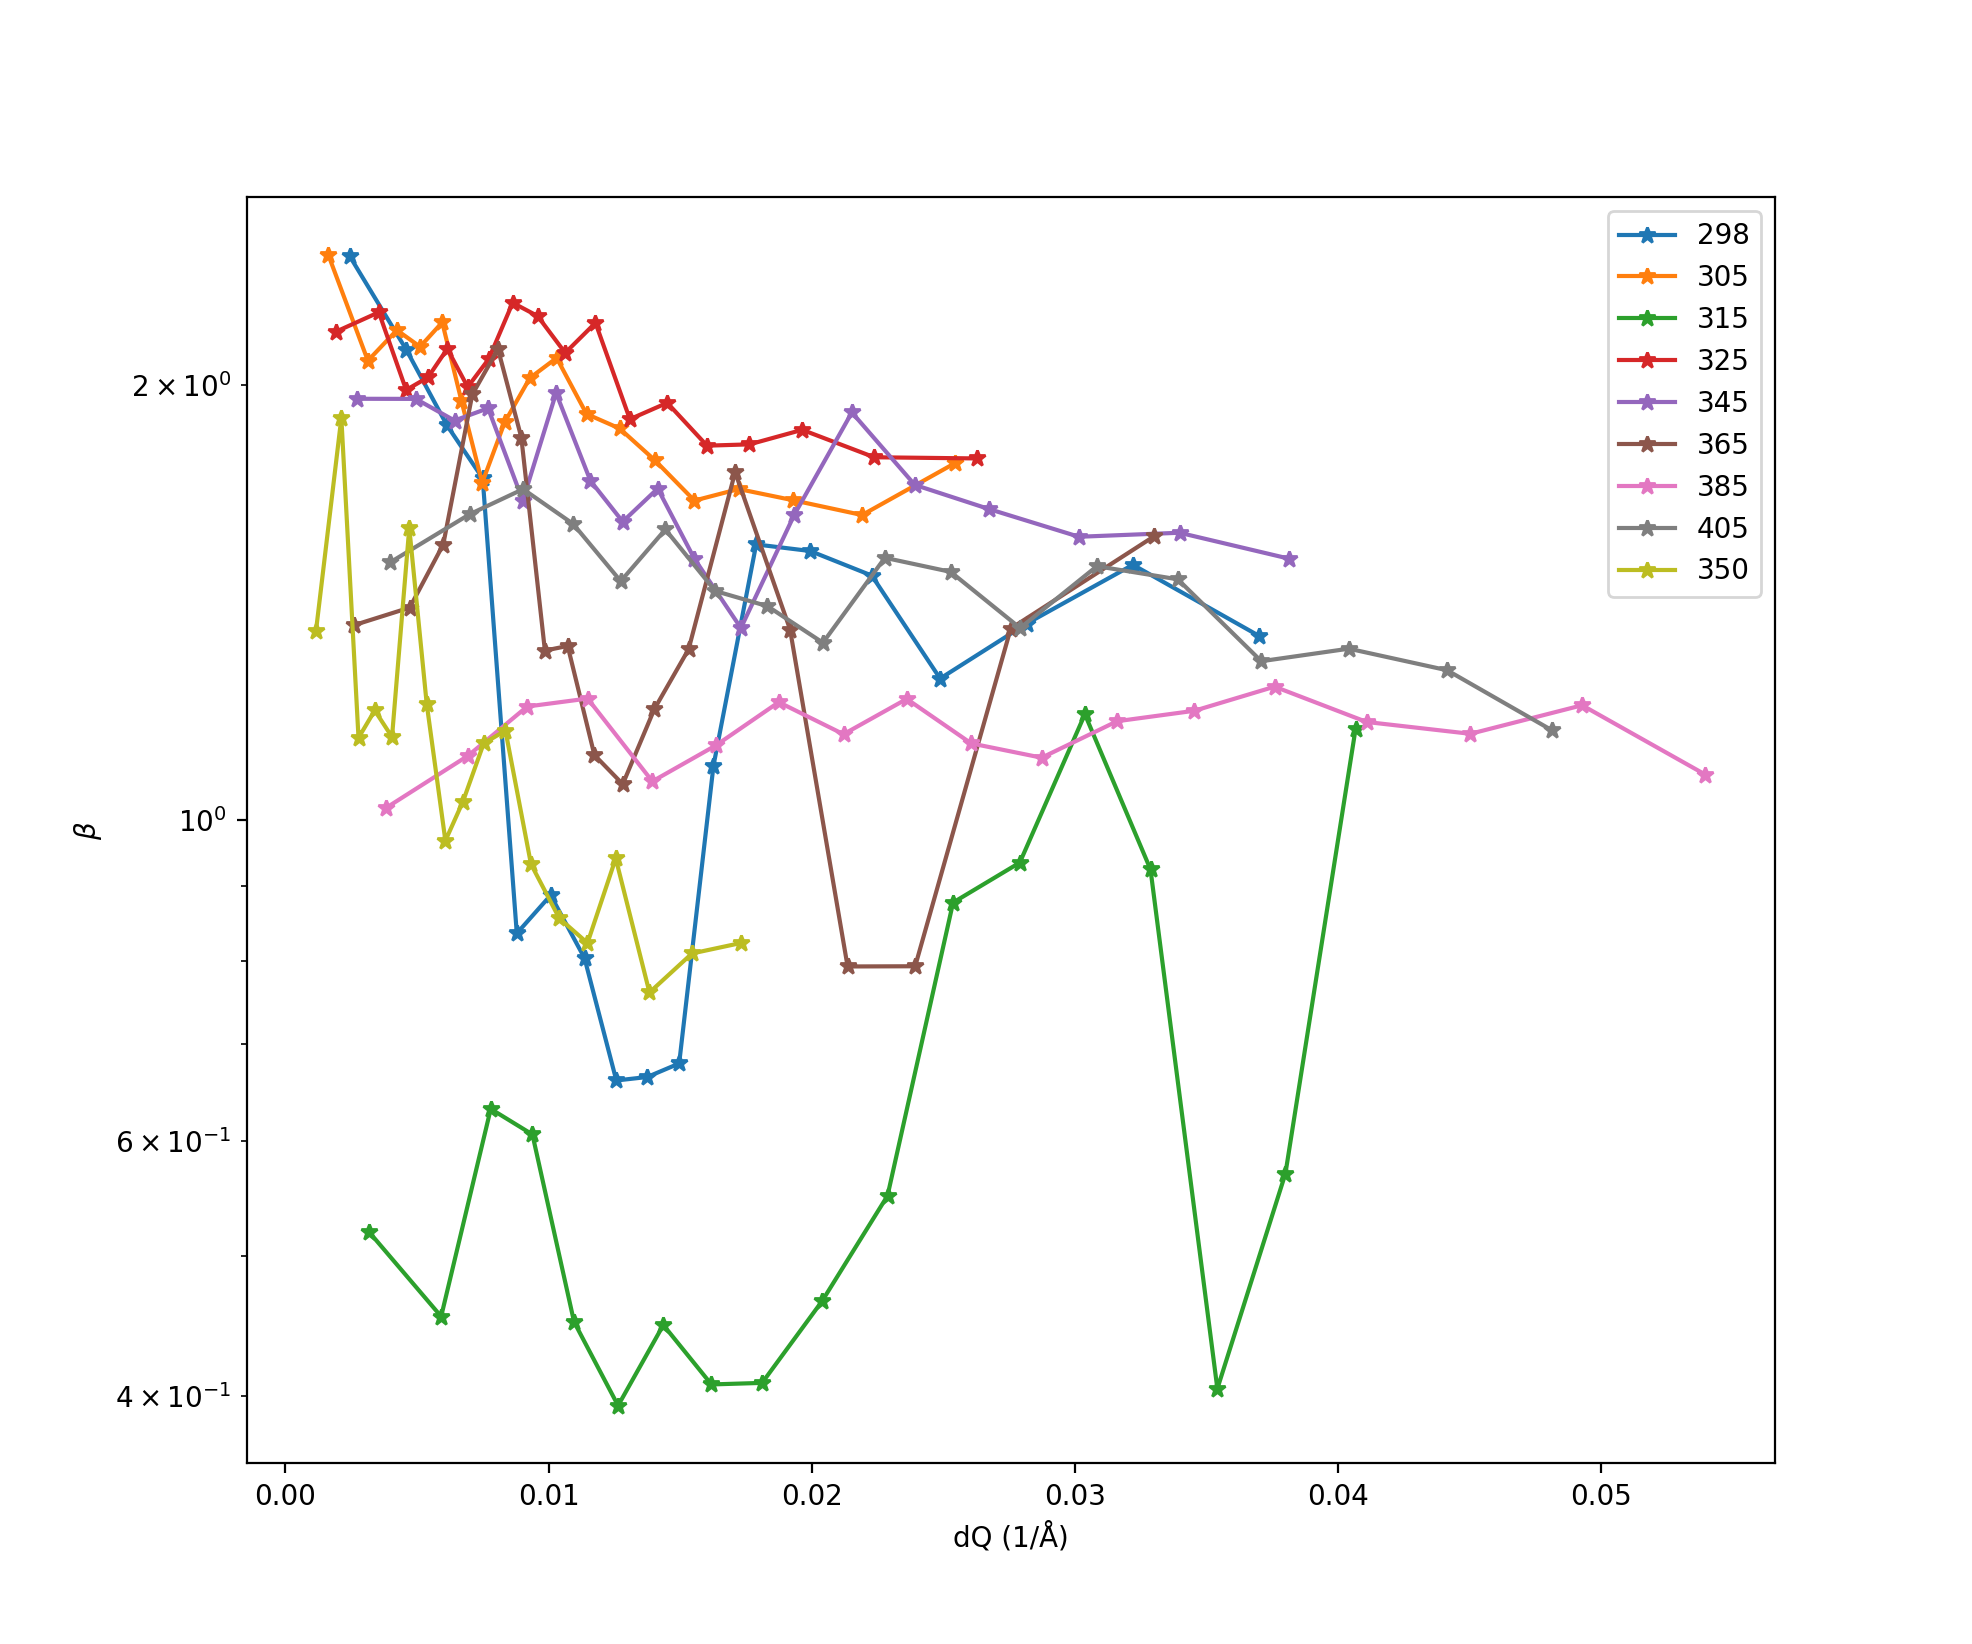

In [120]:
fig, ax = plt.subplots()

ax.set_ylabel('$\\beta$')
ax.set_xlabel('dQ (1/Å)')

for b in range(betas.shape[0]):
    ax.semilogy(dQ[b,:],betas[b,:],'-*',label=T[b])
    ax.legend(loc = 'upper right')
    
    
plt.show()
